In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 1 - Load data and price dataframe

In [2]:
xlu = pd.read_csv('/Users/Sinthu/Desktop/Quant Trading Project/data/xlu.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed
xlp = pd.read_csv('/Users/Sinthu/Desktop/Quant Trading Project/data/xlp.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')   # change if needed

xlu.columns = xlu.columns.str.strip()
xlp.columns = xlp.columns.str.strip()

xlu = pd.DataFrame({'Adj_Close': xlu['Close']})
xlp = pd.DataFrame({'Adj_Close': xlp['Close']})

xlu.sort_index(inplace=True)
xlp.sort_index(inplace=True)

In [3]:
prices = pd.DataFrame({
    "XLU": xlu["Adj_Close"],
    "XLP": xlp["Adj_Close"]
}).dropna()

prices.head()

,XLU,XLP
Date,,
1998-12-22,14.9141,26.5000
1998-12-23,14.8516,27.1406
1998-12-24,15.1250,27.0938
1998-12-28,15.0469,26.9375
1998-12-29,15.2969,27.5313


In [4]:
prices["ratio"] = prices["XLU"] / prices["XLP"]

lookback = 60
prices["ratio_mean"] = prices["ratio"].rolling(lookback).mean()
prices["ratio_std"] = prices["ratio"].rolling(lookback).std()

prices["zscore"] = (prices["ratio"] - prices["ratio_mean"]) / prices["ratio_std"]

In [5]:
#Raw signal

entry_threshold = 2
exit_threshold = 0.5

prices["signal_raw"] = 0
prices.loc[prices["zscore"] < -entry_threshold, "signal_raw"] = 1
prices.loc[prices["zscore"] > entry_threshold, "signal_raw"] = -1

prices["signal_raw"].value_counts(dropna=False)

signal_raw
 0    6047
-1     460
 1     370
Name: count, dtype: int64

In [6]:
prices["position"] = 0

for i in range(1, len(prices)):
    prev_pos = prices["position"].iloc[i-1]
    z = prices["zscore"].iloc[i]
    raw = prices["signal_raw"].iloc[i]
    
    if prev_pos == 0:
        prices.iloc[i, prices.columns.get_loc("position")] = raw
    else:
        if abs(z) <= exit_threshold:
            prices.iloc[i, prices.columns.get_loc("position")] = 0
        else:
            prices.iloc[i, prices.columns.get_loc("position")] = prev_pos

In [14]:
#To avoid look ahead bias

prices["position_shifted"] = prices["position"].shift(1)

In [15]:
prices[["XLU", "XLP", "ratio", "zscore", "signal_raw", "position", "position_shifted"]].head(120)

,XLU,XLP,ratio,zscore,signal_raw,position,position_shifted
Date,,,,,,,
1999-03-19,14.1016,27.6250,0.510465,-1.958044,0,0,NaN
1999-03-22,14.1484,27.6094,0.512449,-1.771927,0,0,0.0
1999-03-23,13.7031,26.8281,0.510774,-1.774954,0,0,0.0
1999-03-24,13.8906,26.8125,0.518064,-1.369379,0,0,0.0
1999-03-25,13.8438,27.0156,0.512437,-1.571753,0,0,0.0
...,...,...,...,...,...,...,...
1999-09-01,14.6875,24.9688,0.588234,-1.329788,0,0,0.0
1999-09-02,14.4844,24.9375,0.580828,-1.758244,0,0,0.0
1999-09-03,14.7578,25.3750,0.581588,-1.648884,0,0,0.0


In [16]:
prices.head()

,XLU,XLP,ratio,ratio_mean,ratio_std,zscore,signal_raw,position,position_shifted,ret_XLU,ret_XLP,spread_return_gross
Date,,,,,,,,,,,,
1999-03-19,14.1016,27.6250,0.510465,0.548799,0.019578,-1.958044,0,0,NaN,-0.024846,-0.006184,-0.0
1999-03-22,14.1484,27.6094,0.512449,0.547960,0.020041,-1.771927,0,0,0.0,0.003319,-0.000565,0.0
1999-03-23,13.7031,26.8281,0.510774,0.547353,0.020608,-1.774954,0,0,0.0,-0.031474,-0.028298,-0.0
1999-03-24,13.8906,26.8125,0.518064,0.546683,0.020899,-1.369379,0,0,0.0,0.013683,-0.000581,0.0
1999-03-25,13.8438,27.0156,0.512437,0.545914,0.021299,-1.571753,0,0,0.0,-0.003369,0.007575,-0.0


# Thursday 23rd April
## Backtest and performance

Step 1 - Check your shifted position

- Checking position is shifted before calculating returns

In [17]:
#Quick check
prices[["zscore", "signal_raw", "position", "position_shifted"]].head(70)

,zscore,signal_raw,position,position_shifted
Date,,,,
1999-03-19,-1.958044,0,0,NaN
1999-03-22,-1.771927,0,0,0.0
1999-03-23,-1.774954,0,0,0.0
1999-03-24,-1.369379,0,0,0.0
1999-03-25,-1.571753,0,0,0.0
...,...,...,...,...
1999-06-22,1.252941,0,-1,-1.0
1999-06-23,1.369849,0,-1,-1.0
1999-06-24,1.204310,0,-1,-1.0


Step 2 - Compute returns for both ETFs

- Since this is a pair strategy, we will need the daily returns of each asset.
- WHY THIS MATTERS: you need return series before you can estimate how the long and short sides behave on a daily basis.

In [18]:
# Returns

prices["ret_XLU"] = prices["XLU"].pct_change()
prices["ret_XLP"] = prices["XLP"].pct_change()
prices = prices.dropna()

Step 3 - Define the pair strategy return

A simple pair-trading assumption is:
- If you are long the spread, you are long XLU and short XLP
- If you are short the spread, you are short XLU and long XLP

For the first version, we will use an equal-weight assumption

In [19]:
# Gross strategy returns

prices.loc[:,"spread_return_gross"] = prices["position_shifted"] * (prices["ret_XLU"] - prices["ret_XLP"])
prices[["position_shifted", "ret_XLU", "ret_XLP", "spread_return_gross"]].head(20)

,position_shifted,ret_XLU,ret_XLP,spread_return_gross
Date,,,,
1999-03-22,0.0,0.003319,-0.000565,0.000000
1999-03-23,0.0,-0.031474,-0.028298,-0.000000
1999-03-24,0.0,0.013683,-0.000581,0.000000
1999-03-25,0.0,-0.003369,0.007575,-0.000000
1999-03-26,0.0,-0.012981,-0.003468,-0.000000
1999-03-29,0.0,-0.005145,0.012767,-0.000000
1999-03-30,1.0,-0.016096,-0.008593,-0.007502
1999-03-31,1.0,-0.002333,-0.021967,0.019634
1999-04-01,1.0,0.021073,0.001774,0.019299


Interpretation

- When position_shifted = 1, you profit if XLU outperforms XLP.
- When position_shifted = -1, you profit if XLP outperforms XLU.

Step 4 - Transcation costs

(This is where many strategy backtests become less exciting).

In [24]:
transaction_cost = 0.001

prices["trade"] = prices["position"].diff().abs().fillna(0)
prices["cost"] = prices["trade"] * transaction_cost

prices["spread_return_net"] = prices["spread_return_gross"] - prices["cost"]

prices[["trade", "cost", "spread_return_gross", "spread_return_net"]].head(20)

,trade,cost,spread_return_gross,spread_return_net
Date,,,,
1999-03-22,0.0,0.000,0.000000,0.000000
1999-03-23,0.0,0.000,-0.000000,-0.000000
1999-03-24,0.0,0.000,0.000000,0.000000
1999-03-25,0.0,0.000,-0.000000,-0.000000
1999-03-26,0.0,0.000,-0.000000,-0.000000
1999-03-29,1.0,0.001,-0.000000,-0.001000
1999-03-30,0.0,0.000,-0.007502,-0.007502
1999-03-31,0.0,0.000,0.019634,0.019634
1999-04-01,0.0,0.000,0.019299,0.019299


WHY THIS MATTERS: A mean reversion strategy can generate frequent trades, so costs can significanally reduce or even destroy the edge.

Step 5 - Build equity curves

In [25]:
#Equity curves

prices["equity_gross"] = (1 + prices["spread_return_gross"]).cumprod()
prices["equity_net"] = (1 + prices["spread_return_net"]).cumprod()

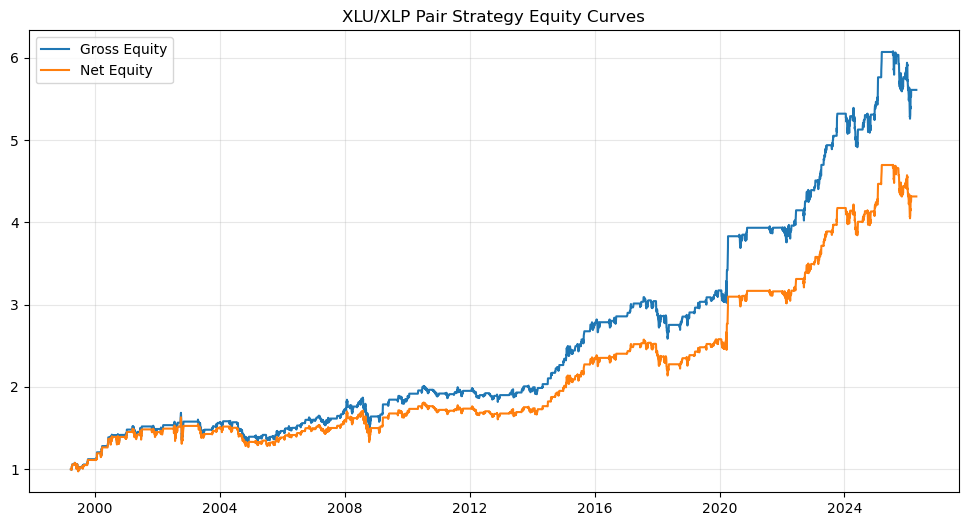

In [26]:
#Plot them

plt.figure(figsize=(12,6))
plt.plot(prices.index, prices["equity_gross"], label="Gross Equity")
plt.plot(prices.index, prices["equity_net"], label="Net Equity")
plt.title("XLU/XLP Pair Strategy Equity Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

WHAT TO LOOK FOR:

Whether the gross line trends upward
- Yes, it does

How much costs reduce the final result
- Key difference in gross and net, costs may a huge impact on returns

Whether net performance is actually worth the effort
- Not particulary takes 16 years to double the initial value, clearly not worth it.

Step 6 - Add a baseline comparison

- For a pair trade, the simplest baseline is to do NOTHING/ stay flat. You can compare your strategy against zero return.

In [27]:
#Flat baseline

prices["flat_return"] = 0.0
prices["flat_equity"] = (1 + prices["flat_return"]).cumprod()

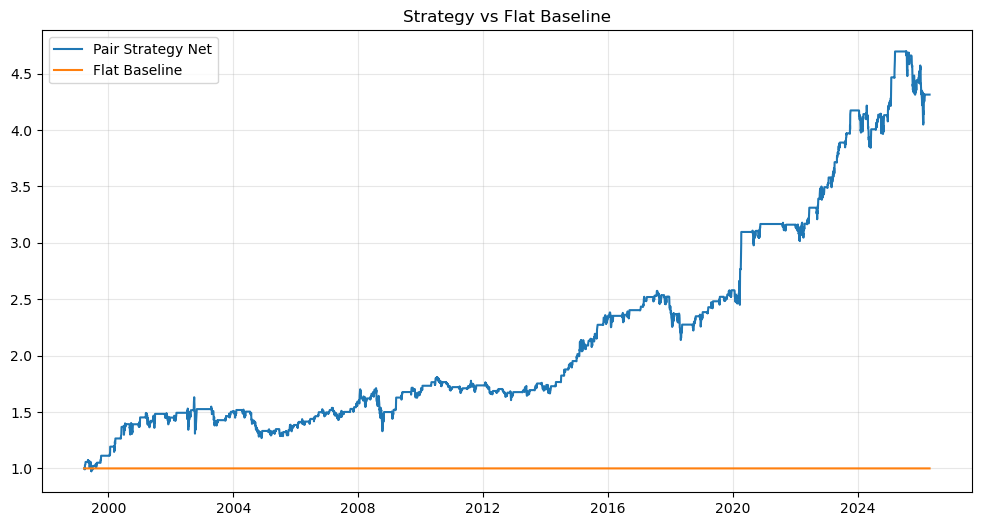

In [28]:
#Compare equity curves

plt.figure(figsize=(12,6))
plt.plot(prices.index, prices["equity_net"], label="Pair Strategy Net")
plt.plot(prices.index, prices["flat_equity"], label="Flat Baseline")
plt.title("Strategy vs Flat Baseline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

WHY THIS MATTERS:
- If your pair strategy does NOT beat "do nothing" after costs, then it is not useful yet.
- In this case it's clear from the plot above the pair strategy beats "doing nothing"

Step 7 - Calculate performance metrics

In [31]:
#Metric functions

def annualized_return(r):
    return (1 + r.mean())**252 - 1

def annualized_vol(r):
    return r.std() * np.sqrt(252)

def sharpe_ratio(r):
    vol = annualized_vol(r)
    return np.nan if vol == 0 else annualized_return(r) / vol

def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

In [32]:
#Summary metrics
metrics = pd.DataFrame({
    "Gross": [
        annualized_return(prices["spread_return_gross"]),
        annualized_vol(prices["spread_return_gross"]),
  
        sharpe_ratio(prices["spread_return_gross"]),
        max_drawdown(prices["equity_gross"])
    ],
    "Net": [
        annualized_return(prices["spread_return_net"]),
        annualized_vol(prices["spread_return_net"]),
        sharpe_ratio(prices["spread_return_net"]),
        max_drawdown(prices["equity_net"])
    ]
}, index=["Annual Return", "Annual Volatility", "Sharpe", "Max Drawdown"])

metrics.round(4)

,Gross,Net
Annual Return,0.0718,0.0614
Annual Volatility,0.1056,0.1051
Sharpe,0.6794,0.5837
Max Drawdown,-0.2231,-0.2231


WHAT TO JUDGE:

Does net Sharpe remain positive?
- Yes

Is max drawdown manageable?
- Yes, they're maanegeable 

Is gross performance much stronger than net performance?
- Yes, drastically as time increases

Step 8 - Count trades

In [35]:
#Trade counts

trade_count = (prices["trade"] > 0).sum()
print(f"Trade count: {trade_count}")

Trade count: 264


WHY IT MATTERS:

- Trade count helps you understand how active the strategy is, and whether costs are likely to be a major issue.

Step 9 - Plot the z-score with entries

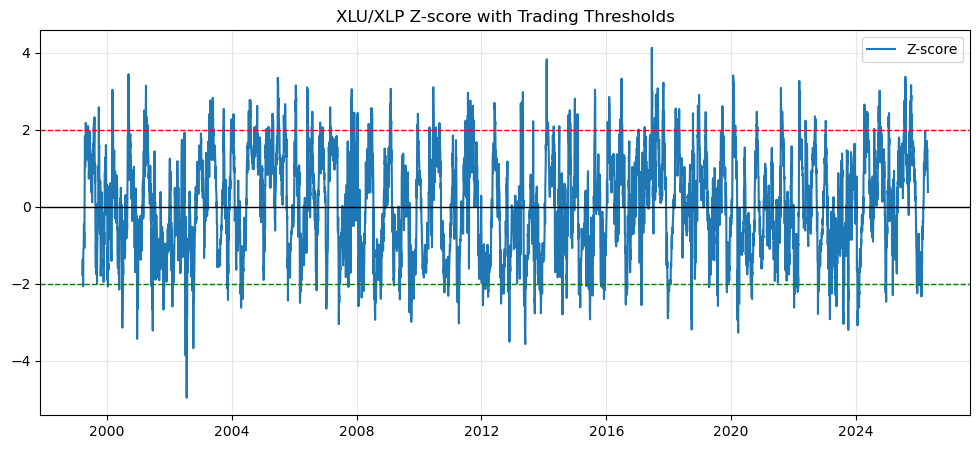

In [36]:
plt.figure(figsize=(12,5))
plt.plot(prices.index, prices["zscore"], label="Z-score")
plt.axhline(entry_threshold, color="red", linestyle="--", linewidth=1)
plt.axhline(-entry_threshold, color="green", linestyle="--", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.title("XLU/XLP Z-score with Trading Thresholds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

WHY THIS MATTERS:

- This helps you see whether the trades are triggered at sensible extremes or whether the thresholds are too loose or too tight.

## Thursday Observations

Whether the strategy made money gross and net.
- The strategy many money gross at annual return of 7.18% and net at annual return of 6.14%. This is a low return rate for gross, making net returns extremely low. Showing the pair is educational but not tradeable yet.

Whether costs mattered a lot.
- Costs signfically mattered for this pair.

Whether the trade count was high or low.
- The trade count was high, this can be a factor for low annual return - something to tweak & maximise.

Whether the equity curve looked stable or erratic.
-  Equity curve looked fairly stable

Whether the pair seems worth further testing.
- The low annual gross return gives reason to not further test, however the fairly low volatility is a positive. Overall, it is still worth further testing to improve the enter/ exit rules.